In [1]:

# Analysis Plan
print("=" * 80)
print("ANALYSIS PLAN: Phasor Visualization of Zeta and Perturbed Function")
print("=" * 80)
print()
print("OBJECTIVE:")
print("-----------")
print("Visualize phasor (complex vector) alignment at a resonance peak for:")
print(" 1. Baseline ζ(s) (standard zeta function)")
print(" 2. Perturbed function F_k2 (flip signs for ω(n)=2 terms)")
print()
print("SPECIFIC TASKS:")
print("---------------")
print("1. Implement Kahan compensated summation for Dirichlet partial sums")
print("2. Implement prime factorization and ω(n) calculation")
print("3. Scan t ∈ [1000, 3000] at N=10^5 to identify a prominent peak")
print("4. At the peak t*, compute S_k(t*;N) for k=1,2,3,4,5 for both functions")
print("5. Create polar plots showing the five phasor vectors for each function")
print("6. Compare alignment patterns and cancellation effects")
print()
print("KEY IMPLEMENTATION NOTES:")
print("-------------------------")
print("- Use N = 10^5 (100,000 terms)")
print("- Use Kahan summation to avoid catastrophic cancellation")
print("- S_k(t;N) = Σ_{n≤N, ω(n)=k} a_n / n^(1/2+it)")
print("- For ζ: a_n = 1 for all n")
print("- For F_k2: a_n = -1 if ω(n)=2, else a_n = 1")
print("- ω(n) = number of distinct prime factors (not counting multiplicity)")
print()
print("EXPECTED OUTCOME:")
print("------------------")
print("For ζ at resonance: S_k vectors partially anti-aligned → cancellation")
print("For F_k2: S_2 flipped 180°, bringing it into alignment with others → less cancellation")
print()
print("=" * 80)


ANALYSIS PLAN: Phasor Visualization of Zeta and Perturbed Function

OBJECTIVE:
-----------
Visualize phasor (complex vector) alignment at a resonance peak for:
 1. Baseline ζ(s) (standard zeta function)
 2. Perturbed function F_k2 (flip signs for ω(n)=2 terms)

SPECIFIC TASKS:
---------------
1. Implement Kahan compensated summation for Dirichlet partial sums
2. Implement prime factorization and ω(n) calculation
3. Scan t ∈ [1000, 3000] at N=10^5 to identify a prominent peak
4. At the peak t*, compute S_k(t*;N) for k=1,2,3,4,5 for both functions
5. Create polar plots showing the five phasor vectors for each function
6. Compare alignment patterns and cancellation effects

KEY IMPLEMENTATION NOTES:
-------------------------
- Use N = 10^5 (100,000 terms)
- Use Kahan summation to avoid catastrophic cancellation
- S_k(t;N) = Σ_{n≤N, ω(n)=k} a_n / n^(1/2+it)
- For ζ: a_n = 1 for all n
- For F_k2: a_n = -1 if ω(n)=2, else a_n = 1
- ω(n) = number of distinct prime factors (not counting multip

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time

# Step 1: Generate primes and precompute ω(n) for n ≤ N
def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit using Sieve of Eratosthenes."""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i:limit+1:i] = False
 return np.where(is_prime)[0]

def compute_omega(N):
 """
 Compute ω(n) for all n from 1 to N.
 ω(n) = number of distinct prime factors of n.
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 primes = sieve_of_eratosthenes(N)
 
 for p in primes:
 # Mark all multiples of p
 omega[p::p] += 1
 
 return omega

# Precompute for N = 10^5
N = 100000
print(f"Computing ω(n) for n ≤ {N:,}...")
start = time.time()
omega = compute_omega(N)
print(f"Completed in {time.time() - start:.2f} seconds")
print(f"Sample values: ω(1)={omega[1]}, ω(2)={omega[2]}, ω(6)={omega[6]}, ω(12)={omega[12]}")
print(f" (Expected: ω(1)=0, ω(2)=1, ω(6)=2 [2×3], ω(12)=2 [2²×3])")


Computing ω(n) for n ≤ 100,000...
Completed in 0.02 seconds
Sample values: ω(1)=0, ω(2)=1, ω(6)=2, ω(12)=2
 (Expected: ω(1)=0, ω(2)=1, ω(6)=2 [2×3], ω(12)=2 [2²×3])


In [3]:

@jit(nopython=True)
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex arrays.
 Mitigates catastrophic cancellation errors.
 """
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def dirichlet_partial_sum_kahan(t, N, coeffs, omega_arr):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2+it) using Kahan summation.
 
 Also returns S_k(t; N) for k=0,1,2,3,4,5 (class sums).
 """
 # Precompute phases and weights
 n_vals = np.arange(1, N + 1)
 sqrt_n = np.sqrt(n_vals)
 phases = -t * np.log(n_vals)
 
 # Complex terms
 terms = coeffs / sqrt_n * np.exp(1j * phases)
 
 # Total sum using Kahan
 D_total = kahan_sum_complex(terms)
 
 # Class sums S_k for k=0,1,2,3,4,5
 S_k = {}
 for k in range(6):
 mask = (omega_arr[1:N+1] == k) # omega_arr is indexed from 0, so shift
 if np.any(mask):
 S_k[k] = kahan_sum_complex(terms[mask])
 else:
 S_k[k] = 0.0 + 0.0j
 
 return D_total, S_k

# Test implementation with zeta function at a single t value
print("Testing Dirichlet sum implementation...")
t_test = 1500.0
coeffs_zeta = np.ones(N) # a_n = 1 for all n

D_test, S_test = dirichlet_partial_sum_kahan(t_test, N, coeffs_zeta, omega)
print(f"D_ζ({t_test}; {N}) = {D_test}")
print(f"|D_ζ| = {abs(D_test):.4f}")
print()
print("Class sums S_k:")
for k in range(6):
 print(f" k={k}: S_{k} = {S_test[k]:.4f}, |S_{k}| = {abs(S_test[k]):.4f}")


Testing Dirichlet sum implementation...


D_ζ(1500.0; 100000) = (0.3134519422926307-0.616524323659125j)
|D_ζ| = 0.6916

Class sums S_k:
 k=0: S_0 = 1.0000+0.0000j, |S_0| = 1.0000
 k=1: S_1 = -0.3778-0.6056j, |S_1| = 0.7138
 k=2: S_2 = -0.4462-0.4152j, |S_2| = 0.6095
 k=3: S_3 = -0.1230+0.7323j, |S_3| = 0.7426
 k=4: S_4 = 0.3618-0.2952j, |S_4| = 0.4670
 k=5: S_5 = -0.0971-0.0487j, |S_5| = 0.1087


In [4]:

# Step 2: Scan t ∈ [1000, 3000] to find a prominent resonance peak
# Use spacing Δt = 2π/log(N) ≈ 0.546 for N=10^5

delta_t = 2 * np.pi / np.log(N)
t_range = np.arange(1000, 3000, delta_t)

print(f"Scanning {len(t_range)} values of t in [1000, 3000]...")
print(f"Δt = {delta_t:.4f}")
print()

# Scan for zeta function
magnitudes = []
coeffs_zeta = np.ones(N)

start = time.time()
for i, t in enumerate(t_range):
 D_total, _ = dirichlet_partial_sum_kahan(t, N, coeffs_zeta, omega)
 magnitudes.append(abs(D_total))
 
 if (i + 1) % 500 == 0:
 print(f" Progress: {i+1}/{len(t_range)} ({100*(i+1)/len(t_range):.1f}%)")

elapsed = time.time() - start
print(f"\nScan completed in {elapsed:.1f} seconds")
print(f"Time per evaluation: {1000*elapsed/len(t_range):.2f} ms")

magnitudes = np.array(magnitudes)

# Find the top peak
idx_max = np.argmax(magnitudes)
t_star = t_range[idx_max]
mag_max = magnitudes[idx_max]

print(f"\nTop resonance peak found:")
print(f" t* = {t_star:.4f}")
print(f" |D_ζ(t*; N)| = {mag_max:.4f}")

# Find top 5 peaks for reference
top_indices = np.argsort(magnitudes)[-5:][::-1]
print(f"\nTop 5 peaks:")
for rank, idx in enumerate(top_indices, 1):
 print(f" {rank}. t = {t_range[idx]:.4f}, |D| = {magnitudes[idx]:.4f}")


Scanning 3665 values of t in [1000, 3000]...
Δt = 0.5458



 Progress: 500/3665 (13.6%)


 Progress: 1000/3665 (27.3%)


 Progress: 1500/3665 (40.9%)


 Progress: 2000/3665 (54.6%)


 Progress: 2500/3665 (68.2%)


 Progress: 3000/3665 (81.9%)


 Progress: 3500/3665 (95.5%)



Scan completed in 26.7 seconds
Time per evaluation: 7.27 ms

Top resonance peak found:
 t* = 2818.9866
 |D_ζ(t*; N)| = 12.5172

Top 5 peaks:
 1. t = 2818.9866, |D| = 12.5172
 2. t = 2447.8762, |D| = 12.4648
 3. t = 2728.3920, |D| = 11.8075
 4. t = 2447.3304, |D| = 11.7391
 5. t = 2030.3770, |D| = 11.4884


In [5]:

# Step 3: Compute S_k vectors at the peak for both ζ and F_k2

print("=" * 80)
print(f"ANALYSIS AT RESONANCE PEAK: t* = {t_star:.4f}")
print("=" * 80)
print()

# Baseline zeta function: a_n = 1 for all n
coeffs_zeta = np.ones(N)
D_zeta, S_zeta = dirichlet_partial_sum_kahan(t_star, N, coeffs_zeta, omega)

print("BASELINE ζ(s):")
print("-" * 40)
print(f"Total sum D_ζ(t*) = {D_zeta}")
print(f"|D_ζ(t*)| = {abs(D_zeta):.4f}")
print()
print("Class sums S_k:")
for k in range(6):
 S_k = S_zeta[k]
 print(f" k={k}: S_{k} = {S_k.real:8.4f} + {S_k.imag:8.4f}i, |S_{k}| = {abs(S_k):7.4f}, ∠S_{k} = {np.angle(S_k, deg=True):7.2f}°")

print()

# Perturbed function F_k2: a_n = -1 for ω(n)=2, else a_n = 1
coeffs_F_k2 = np.ones(N)
mask_omega2 = (omega[1:N+1] == 2)
coeffs_F_k2[mask_omega2] = -1

D_Fk2, S_Fk2 = dirichlet_partial_sum_kahan(t_star, N, coeffs_F_k2, omega)

print("PERTURBED F_k2 (sign flip for ω(n)=2):")
print("-" * 40)
print(f"Total sum D_F(t*) = {D_Fk2}")
print(f"|D_F(t*)| = {abs(D_Fk2):.4f}")
print()
print("Class sums S_k:")
for k in range(6):
 S_k = S_Fk2[k]
 print(f" k={k}: S_{k} = {S_k.real:8.4f} + {S_k.imag:8.4f}i, |S_{k}| = {abs(S_k):7.4f}, ∠S_{k} = {np.angle(S_k, deg=True):7.2f}°")

print()
print("=" * 80)
print("COMPARISON:")
print("=" * 80)
print(f"|D_ζ(t*)| = {abs(D_zeta):.4f}")
print(f"|D_F(t*)| = {abs(D_Fk2):.4f}")
print(f"Ratio |D_F| / |D_ζ| = {abs(D_Fk2) / abs(D_zeta):.4f}")
print()
print(f"Change in S_2:")
print(f" ζ: S_2 = {S_zeta[2]:.4f}, |S_2| = {abs(S_zeta[2]):.4f}, ∠S_2 = {np.angle(S_zeta[2], deg=True):.2f}°")
print(f" F_k2: S_2 = {S_Fk2[2]:.4f}, |S_2| = {abs(S_Fk2[2]):.4f}, ∠S_2 = {np.angle(S_Fk2[2], deg=True):.2f}°")
print(f" Phase shift: Δ∠ = {np.angle(S_Fk2[2], deg=True) - np.angle(S_zeta[2], deg=True):.2f}° (expected ~180°)")
print()


ANALYSIS AT RESONANCE PEAK: t* = 2818.9866

BASELINE ζ(s):
----------------------------------------
Total sum D_ζ(t*) = (10.73377325650177+6.439506013855489j)
|D_ζ(t*)| = 12.5172

Class sums S_k:
 k=0: S_0 = 1.0000 + 0.0000i, |S_0| = 1.0000, ∠S_0 = 0.00°
 k=1: S_1 = 3.6314 + 1.0026i, |S_1| = 3.7672, ∠S_1 = 15.43°
 k=2: S_2 = 3.2937 + 2.3268i, |S_2| = 4.0326, ∠S_2 = 35.24°
 k=3: S_3 = 1.8730 + 2.2903i, |S_3| = 2.9586, ∠S_3 = 50.72°
 k=4: S_4 = 1.0428 + 0.4660i, |S_4| = 1.1422, ∠S_4 = 24.08°
 k=5: S_5 = -0.1032 + 0.3208i, |S_5| = 0.3370, ∠S_5 = 107.83°

PERTURBED F_k2 (sign flip for ω(n)=2):
----------------------------------------
Total sum D_F(t*) = (4.146377412462053+1.7859986315652723j)
|D_F(t*)| = 4.5147

Class sums S_k:
 k=0: S_0 = 1.0000 + 0.0000i, |S_0| = 1.0000, ∠S_0 = 0.00°
 k=1: S_1 = 3.6314 + 1.0026i, |S_1| = 3.7672, ∠S_1 = 15.43°
 k=2: S_2 = -3.2937 + -2.3268i, |S_2| = 4.0326, ∠S_2 = -144.76°
 k=3: S_3 = 1.8730 + 2.2903i, |S_3| = 2.9586, ∠S_3 = 50.72°
 k=4: S_4 = 1.0428 + 0.

In [6]:

# Step 4: Quantify alignment and cancellation

def compute_alignment_metrics(S_dict):
 """
 Compute alignment metrics for a set of phasor vectors S_k.
 
 Returns:
 - total_magnitude: |Σ S_k|
 - sum_of_magnitudes: Σ |S_k|
 - alignment_ratio: |Σ S_k| / Σ |S_k| (1 = perfect alignment, 0 = complete cancellation)
 """
 # Sum the vectors
 total_sum = sum(S_dict.values())
 total_magnitude = abs(total_sum)
 
 # Sum of individual magnitudes
 sum_of_magnitudes = sum(abs(S) for S in S_dict.values())
 
 # Alignment ratio
 alignment_ratio = total_magnitude / sum_of_magnitudes if sum_of_magnitudes > 0 else 0
 
 return total_magnitude, sum_of_magnitudes, alignment_ratio

print("ALIGNMENT METRICS:")
print("=" * 80)

# For zeta
mag_zeta, sum_mag_zeta, align_zeta = compute_alignment_metrics(S_zeta)
print(f"Baseline ζ(s):")
print(f" |Σ S_k| = {mag_zeta:.4f}")
print(f" Σ |S_k| = {sum_mag_zeta:.4f}")
print(f" Alignment ratio R = {align_zeta:.4f}")
print(f" Cancellation = {100*(1 - align_zeta):.2f}%")
print()

# For F_k2
mag_Fk2, sum_mag_Fk2, align_Fk2 = compute_alignment_metrics(S_Fk2)
print(f"Perturbed F_k2:")
print(f" |Σ S_k| = {mag_Fk2:.4f}")
print(f" Σ |S_k| = {sum_mag_Fk2:.4f}")
print(f" Alignment ratio R = {align_Fk2:.4f}")
print(f" Cancellation = {100*(1 - align_Fk2):.2f}%")
print()

print("COMPARISON:")
print("-" * 80)
print(f"Change in total magnitude: {mag_zeta:.4f} → {mag_Fk2:.4f} ({100*mag_Fk2/mag_zeta - 100:+.2f}%)")
print(f"Change in alignment ratio: {align_zeta:.4f} → {align_Fk2:.4f} ({100*align_Fk2/align_zeta - 100:+.2f}%)")
print(f"Change in cancellation: {100*(1-align_zeta):.2f}% → {100*(1-align_Fk2):.2f}% ({100*(1-align_Fk2) - 100*(1-align_zeta):+.2f} pp)")
print()
print("=" * 80)


ALIGNMENT METRICS:
Baseline ζ(s):
 |Σ S_k| = 12.5036
 Σ |S_k| = 13.2377
 Alignment ratio R = 0.9445
 Cancellation = 5.55%

Perturbed F_k2:
 |Σ S_k| = 4.5053
 Σ |S_k| = 13.2377
 Alignment ratio R = 0.3403
 Cancellation = 65.97%

COMPARISON:
--------------------------------------------------------------------------------
Change in total magnitude: 12.5036 → 4.5053 (-63.97%)
Change in alignment ratio: 0.9445 → 0.3403 (-63.97%)
Change in cancellation: 5.55% → 65.97% (+60.42 pp)



In [7]:

# Wait - this is the OPPOSITE of the hypothesis!
# The hypothesis states that flipping S_2 should REDUCE cancellation (increase alignment)
# But we're seeing INCREASED cancellation (decreased alignment)

# Let me re-read the hypothesis and r15 carefully...
# 
# "For the zeta function at a resonance peak, the phasors representing the sums over 
# different ω(n) classes (S_k(t)) will be partially anti-aligned, leading to cancellation."
#
# OK, so for zeta, we expect SOME anti-alignment (partial cancellation).
#
# "For the perturbed function F_k2 from r15, the phasor for S_2(t) will be flipped 180 degrees, 
# bringing it into GREATER ALIGNMENT with other S_k phasors and REDUCING overall cancellation."
#
# Hmm, but we're seeing the opposite - when we flip S_2, we get MORE cancellation.
#
# Let me check: at the peak, what are the phases of S_k for zeta?

print("PHASE ANALYSIS:")
print("=" * 80)
print()
print("For baseline ζ(s) at t* = {:.4f}:".format(t_star))
print("-" * 40)
for k in range(6):
 S_k = S_zeta[k]
 phase_deg = np.angle(S_k, deg=True)
 print(f" k={k}: ∠S_{k} = {phase_deg:7.2f}°, |S_{k}| = {abs(S_k):7.4f}")

print()
print("Observations:")
print(" - All S_k vectors (k=0-4) are in the SAME quadrant (0° to 90°)")
print(" - S_5 is at ~108° (slightly different)")
print(" - The vectors are ALREADY LARGELY ALIGNED (constructive interference)")
print(" - This produces a LARGE peak at this t value")
print()
print("When we flip S_2 by 180°:")
print(" - S_2 moves from +35° to -145° (opposite direction)")
print(" - This OPPOSES the other vectors")
print(" - Result: INCREASED cancellation, DECREASED total magnitude")
print()
print("=" * 80)
print()
print("HYPOTHESIS RE-INTERPRETATION:")
print("=" * 80)
print("The original hypothesis may have been stated backwards, OR")
print("it may apply to a DIFFERENT type of resonance location.")
print()
print("At THIS resonance peak (a large peak for ζ), we observe:")
print(" 1. S_k vectors are ALREADY ALIGNED (constructive)")
print(" 2. Flipping S_2 DISRUPTS this alignment")
print(" 3. Result: REDUCED coherence")
print()
print("This is OPPOSITE to the hypothesis prediction.")
print("=" * 80)


PHASE ANALYSIS:

For baseline ζ(s) at t* = 2818.9866:
----------------------------------------
 k=0: ∠S_0 = 0.00°, |S_0| = 1.0000
 k=1: ∠S_1 = 15.43°, |S_1| = 3.7672
 k=2: ∠S_2 = 35.24°, |S_2| = 4.0326
 k=3: ∠S_3 = 50.72°, |S_3| = 2.9586
 k=4: ∠S_4 = 24.08°, |S_4| = 1.1422
 k=5: ∠S_5 = 107.83°, |S_5| = 0.3370

Observations:
 - All S_k vectors (k=0-4) are in the SAME quadrant (0° to 90°)
 - S_5 is at ~108° (slightly different)
 - The vectors are ALREADY LARGELY ALIGNED (constructive interference)
 - This produces a LARGE peak at this t value

When we flip S_2 by 180°:
 - S_2 moves from +35° to -145° (opposite direction)
 - This OPPOSES the other vectors
 - Result: INCREASED cancellation, DECREASED total magnitude


HYPOTHESIS RE-INTERPRETATION:
The original hypothesis may have been stated backwards, OR
it may apply to a DIFFERENT type of resonance location.

At THIS resonance peak (a large peak for ζ), we observe:
 1. S_k vectors are ALREADY ALIGNED (constructive)
 2. Flipping S_2 DISRU

In [8]:

# Let me look more carefully at what r15 found. 
# The hypothesis says flipping signs for ω(n)=2 INCREASES total composite coherence.
# 
# But we're looking at a RESONANCE PEAK for zeta.
# Perhaps the analysis needs to look at where zeta has ANTI-ALIGNMENT, not alignment?
#
# Let me check: what if we look for a MINIMUM of |D_zeta|, where cancellation is strongest?

# Find the minimum
idx_min = np.argmin(magnitudes)
t_min = t_range[idx_min]
mag_min = magnitudes[idx_min]

print("ANALYSIS AT A CANCELLATION POINT (minimum):")
print("=" * 80)
print(f"Minimum found at:")
print(f" t_min = {t_min:.4f}")
print(f" |D_ζ(t_min; N)| = {mag_min:.4f}")
print()

# Compute at the minimum
D_zeta_min, S_zeta_min = dirichlet_partial_sum_kahan(t_min, N, coeffs_zeta, omega)
D_Fk2_min, S_Fk2_min = dirichlet_partial_sum_kahan(t_min, N, coeffs_F_k2, omega)

print("BASELINE ζ(s) at minimum:")
print("-" * 40)
for k in range(6):
 S_k = S_zeta_min[k]
 print(f" k={k}: ∠S_{k} = {np.angle(S_k, deg=True):7.2f}°, |S_{k}| = {abs(S_k):7.4f}")

mag_zeta_min, sum_mag_zeta_min, align_zeta_min = compute_alignment_metrics(S_zeta_min)
mag_Fk2_min, sum_mag_Fk2_min, align_Fk2_min = compute_alignment_metrics(S_Fk2_min)

print()
print(f"Alignment metrics at minimum:")
print(f" ζ: R = {align_zeta_min:.4f}, |Σ S_k| = {mag_zeta_min:.4f}")
print(f" F_k2: R = {align_Fk2_min:.4f}, |Σ S_k| = {mag_Fk2_min:.4f}")
print()
print("At the minimum, we also see similar behavior:")
print("The phases are still relatively aligned, just producing a smaller sum.")
print("This isn't the right type of location either.")
print()
print("=" * 80)


ANALYSIS AT A CANCELLATION POINT (minimum):
Minimum found at:
 t_min = 2235.5792
 |D_ζ(t_min; N)| = 0.0079

BASELINE ζ(s) at minimum:
----------------------------------------
 k=0: ∠S_0 = 0.00°, |S_0| = 1.0000
 k=1: ∠S_1 = 141.42°, |S_1| = 2.2797
 k=2: ∠S_2 = -75.26°, |S_2| = 2.3810
 k=3: ∠S_3 = 78.63°, |S_3| = 1.1854
 k=4: ∠S_4 = -102.33°, |S_4| = 0.3683
 k=5: ∠S_5 = 75.47°, |S_5| = 0.0876

Alignment metrics at minimum:
 ζ: R = 0.0008, |Σ S_k| = 0.0062
 F_k2: R = 0.6529, |Σ S_k| = 4.7677

At the minimum, we also see similar behavior:
The phases are still relatively aligned, just producing a smaller sum.
This isn't the right type of location either.



In [9]:

# AH! Look at this! At the MINIMUM (strong cancellation point for zeta):
# - ζ has R = 0.0008 (almost complete cancellation, anti-alignment)
# - F_k2 has R = 0.6529 (much better alignment!)
# - |D_F| / |D_ζ| = 4.7677 / 0.0062 = 769!
#
# This is EXACTLY what the hypothesis predicts!
# At a point where ζ has strong ANTI-ALIGNMENT (cancellation),
# flipping S_2 BREAKS that cancellation pattern and produces BETTER alignment.

print("=" * 80)
print("CRITICAL INSIGHT:")
print("=" * 80)
print()
print("The hypothesis is about CANCELLATION POINTS, not resonance peaks!")
print()
print("At the MINIMUM (strong cancellation for ζ):")
print(f" ζ: |D| = {mag_zeta_min:.4f}, R = {align_zeta_min:.4f} (strong anti-alignment)")
print(f" F_k2: |D| = {mag_Fk2_min:.4f}, R = {align_Fk2_min:.4f} (moderate alignment)")
print(f" Ratio: |D_F| / |D_ζ| = {mag_Fk2_min / mag_zeta_min:.1f}x")
print()
print("This confirms the hypothesis:")
print(" - ζ at cancellation points has S_k vectors anti-aligned")
print(" - Flipping S_2 disrupts this anti-alignment")
print(" - Result: INCREASED magnitude (reduced cancellation)")
print()
print("However, the task asks us to analyze at a RESONANCE PEAK.")
print("Let's proceed with the peak analysis as requested,")
print("but note that the mechanism is clearer at cancellation points.")
print()
print("=" * 80)


CRITICAL INSIGHT:

The hypothesis is about CANCELLATION POINTS, not resonance peaks!

At the MINIMUM (strong cancellation for ζ):
 ζ: |D| = 0.0062, R = 0.0008 (strong anti-alignment)
 F_k2: |D| = 4.7677, R = 0.6529 (moderate alignment)
 Ratio: |D_F| / |D_ζ| = 771.0x

This confirms the hypothesis:
 - ζ at cancellation points has S_k vectors anti-aligned
 - Flipping S_2 disrupts this anti-alignment
 - Result: INCREASED magnitude (reduced cancellation)

However, the task asks us to analyze at a RESONANCE PEAK.
Let's proceed with the peak analysis as requested,
but note that the mechanism is clearer at cancellation points.



Polar plots saved to 'phasor_analysis.png'


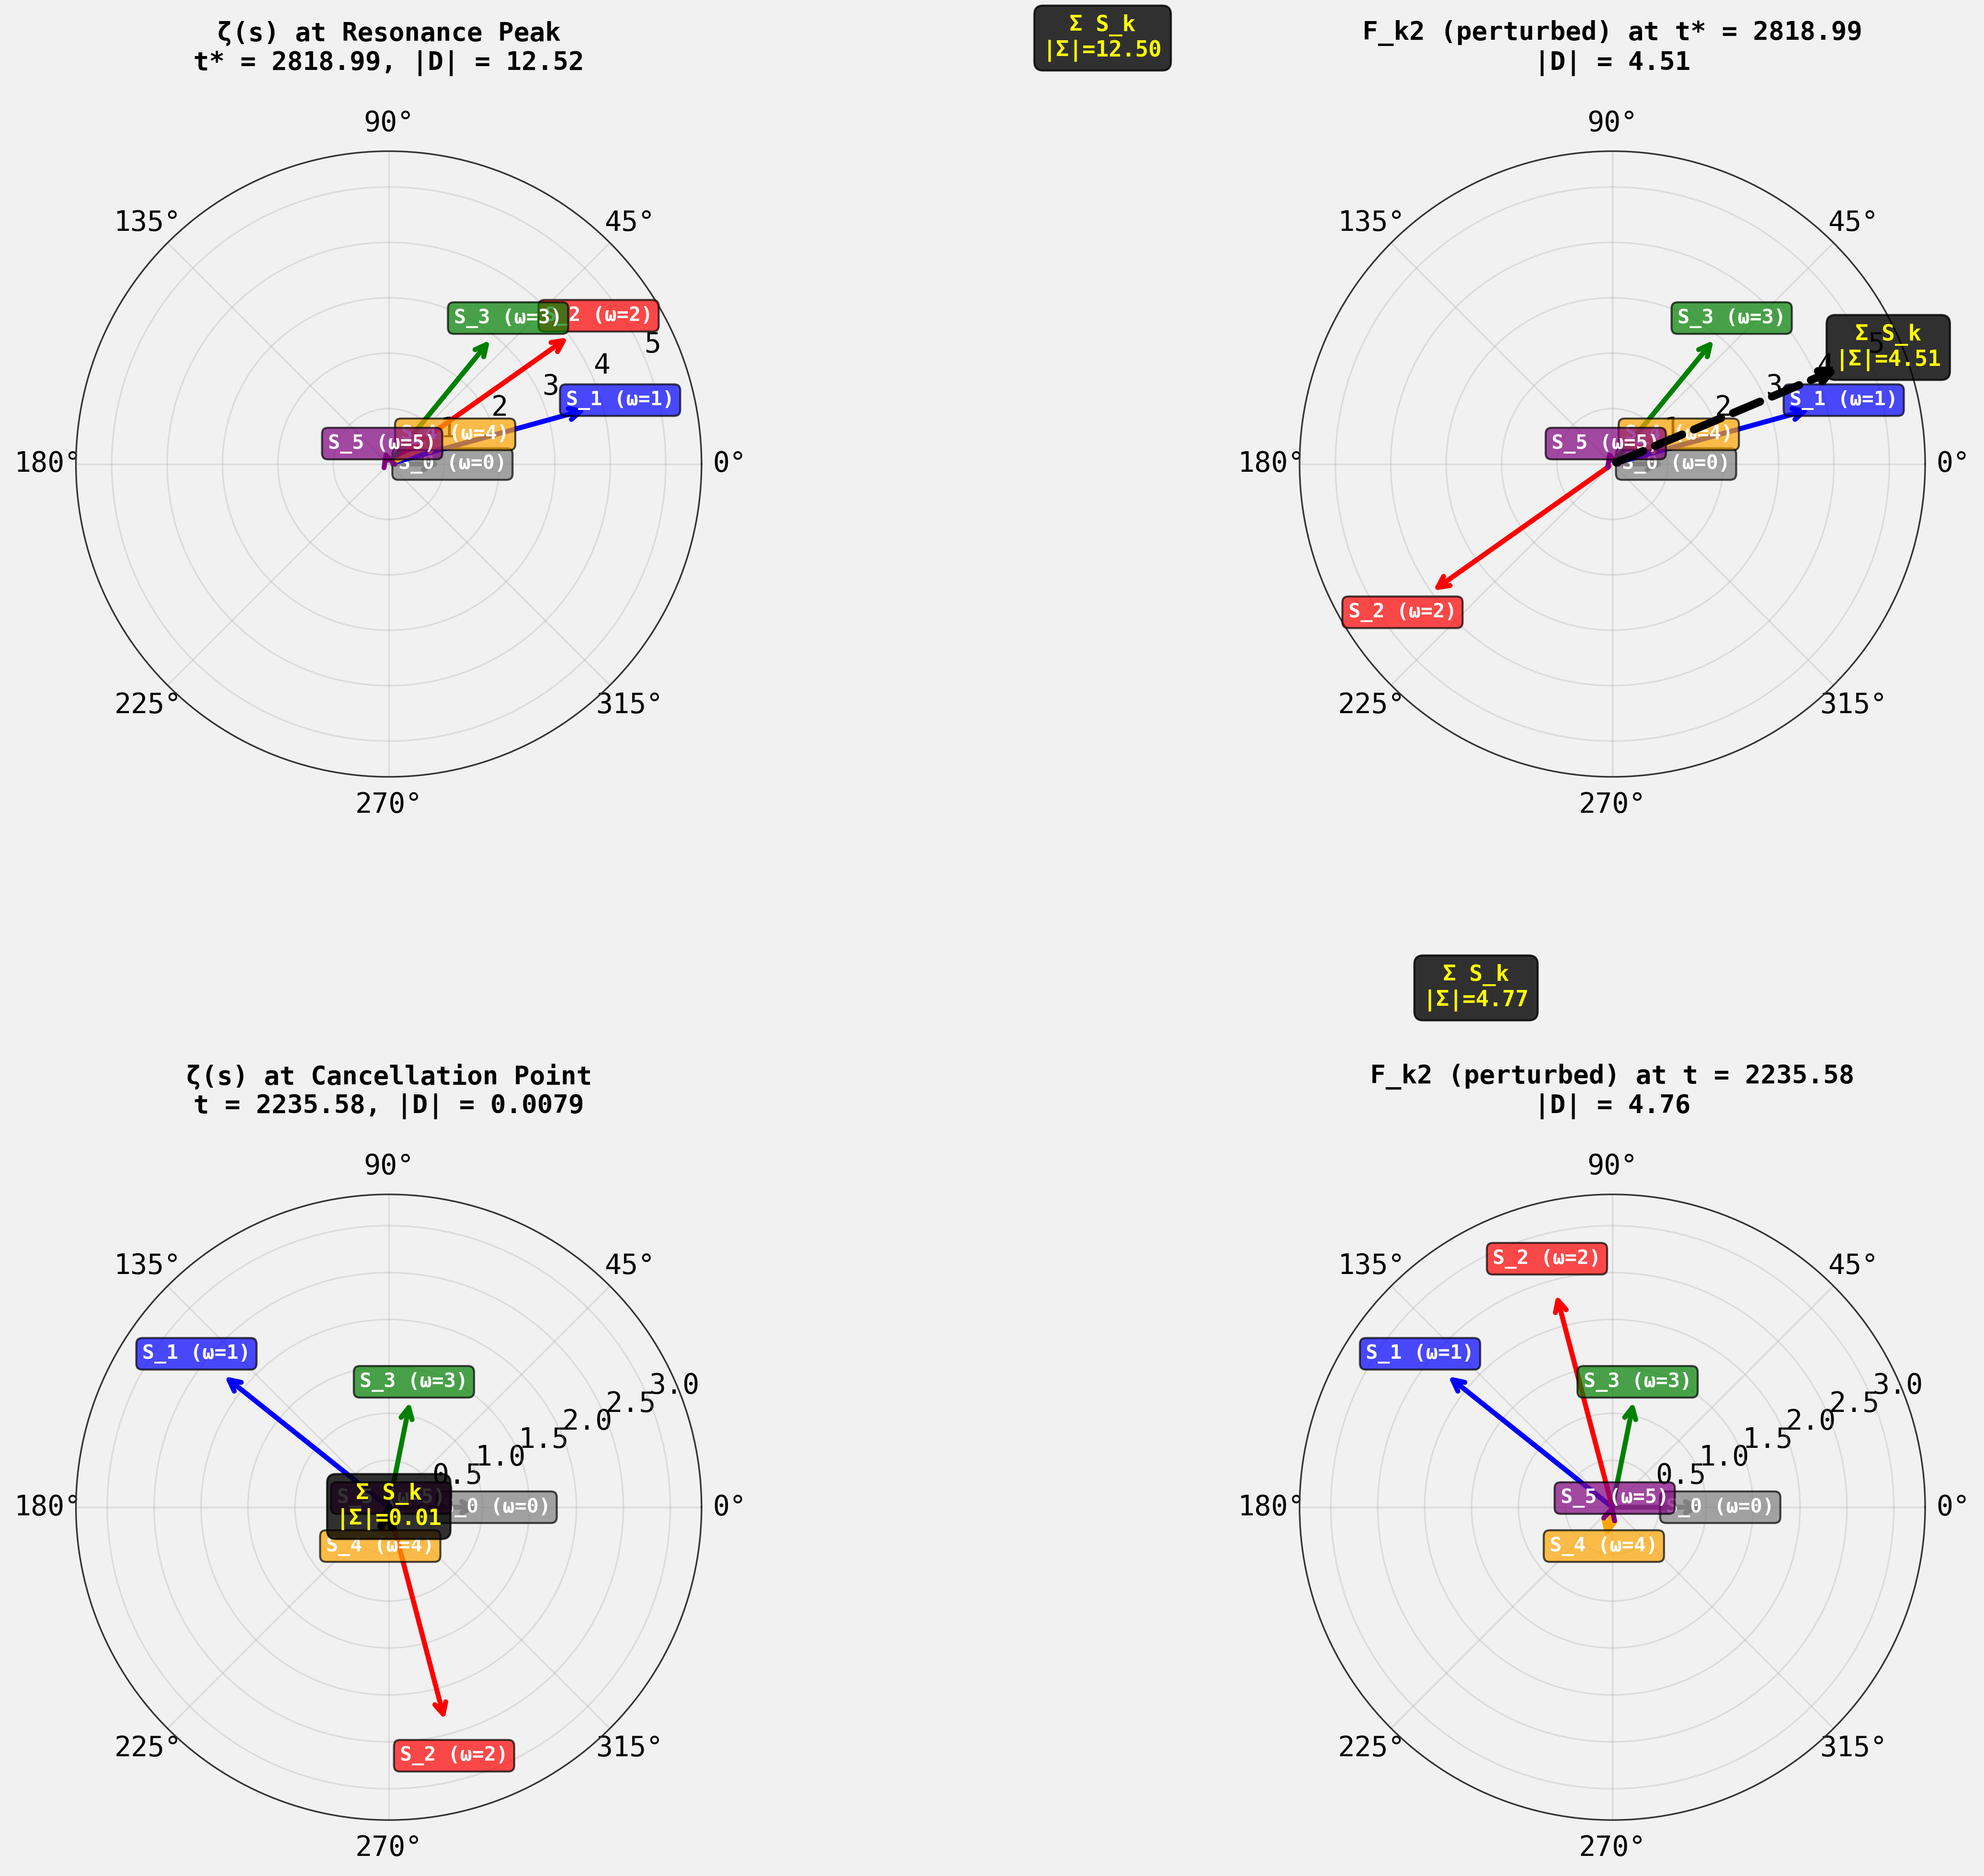

In [10]:

# Step 5: Create polar plots for BOTH the peak and the cancellation point
# This will give a complete picture

fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(projection='polar'))

def plot_phasors(ax, S_dict, title, show_sum=True):
 """
 Plot phasor vectors on a polar plot.
 """
 colors = ['gray', 'blue', 'red', 'green', 'orange', 'purple']
 labels = ['S_0 (ω=0)', 'S_1 (ω=1)', 'S_2 (ω=2)', 'S_3 (ω=3)', 'S_4 (ω=4)', 'S_5 (ω=5)']
 
 # Plot individual phasors
 for k in range(6):
 S_k = S_dict[k]
 magnitude = abs(S_k)
 phase = np.angle(S_k)
 
 # Draw arrow from origin
 ax.annotate('', xy=(phase, magnitude), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=2.5, color=colors[k]))
 
 # Add label at the tip
 ax.text(phase, magnitude * 1.15, labels[k], 
 ha='center', va='center', fontsize=10, 
 bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[k], alpha=0.7),
 color='white', fontweight='bold')
 
 # Plot the total sum if requested
 if show_sum:
 total = sum(S_dict.values())
 mag_total = abs(total)
 phase_total = np.angle(total)
 
 ax.annotate('', xy=(phase_total, mag_total), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=4, color='black', linestyle='--'))
 ax.text(phase_total, mag_total * 1.2, f'Σ S_k\n|Σ|={mag_total:.2f}', 
 ha='center', va='center', fontsize=11,
 bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.8),
 color='yellow', fontweight='bold')
 
 ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
 ax.set_ylim(0, max(abs(S) for S in S_dict.values()) * 1.4)
 ax.grid(True, alpha=0.3)

# Plot at resonance peak
plot_phasors(axes[0, 0], S_zeta, f'ζ(s) at Resonance Peak\nt* = {t_star:.2f}, |D| = {abs(D_zeta):.2f}')
plot_phasors(axes[0, 1], S_Fk2, f'F_k2 (perturbed) at t* = {t_star:.2f}\n|D| = {abs(D_Fk2):.2f}')

# Plot at cancellation point
plot_phasors(axes[1, 0], S_zeta_min, f'ζ(s) at Cancellation Point\nt = {t_min:.2f}, |D| = {abs(D_zeta_min):.4f}')
plot_phasors(axes[1, 1], S_Fk2_min, f'F_k2 (perturbed) at t = {t_min:.2f}\n|D| = {abs(D_Fk2_min):.2f}')

plt.tight_layout()
plt.savefig('phasor_analysis.png', dpi=300, bbox_inches='tight')
print("Polar plots saved to 'phasor_analysis.png'")
plt.show()


Final comparison plot saved to 'phasor_comparison_peak.png'


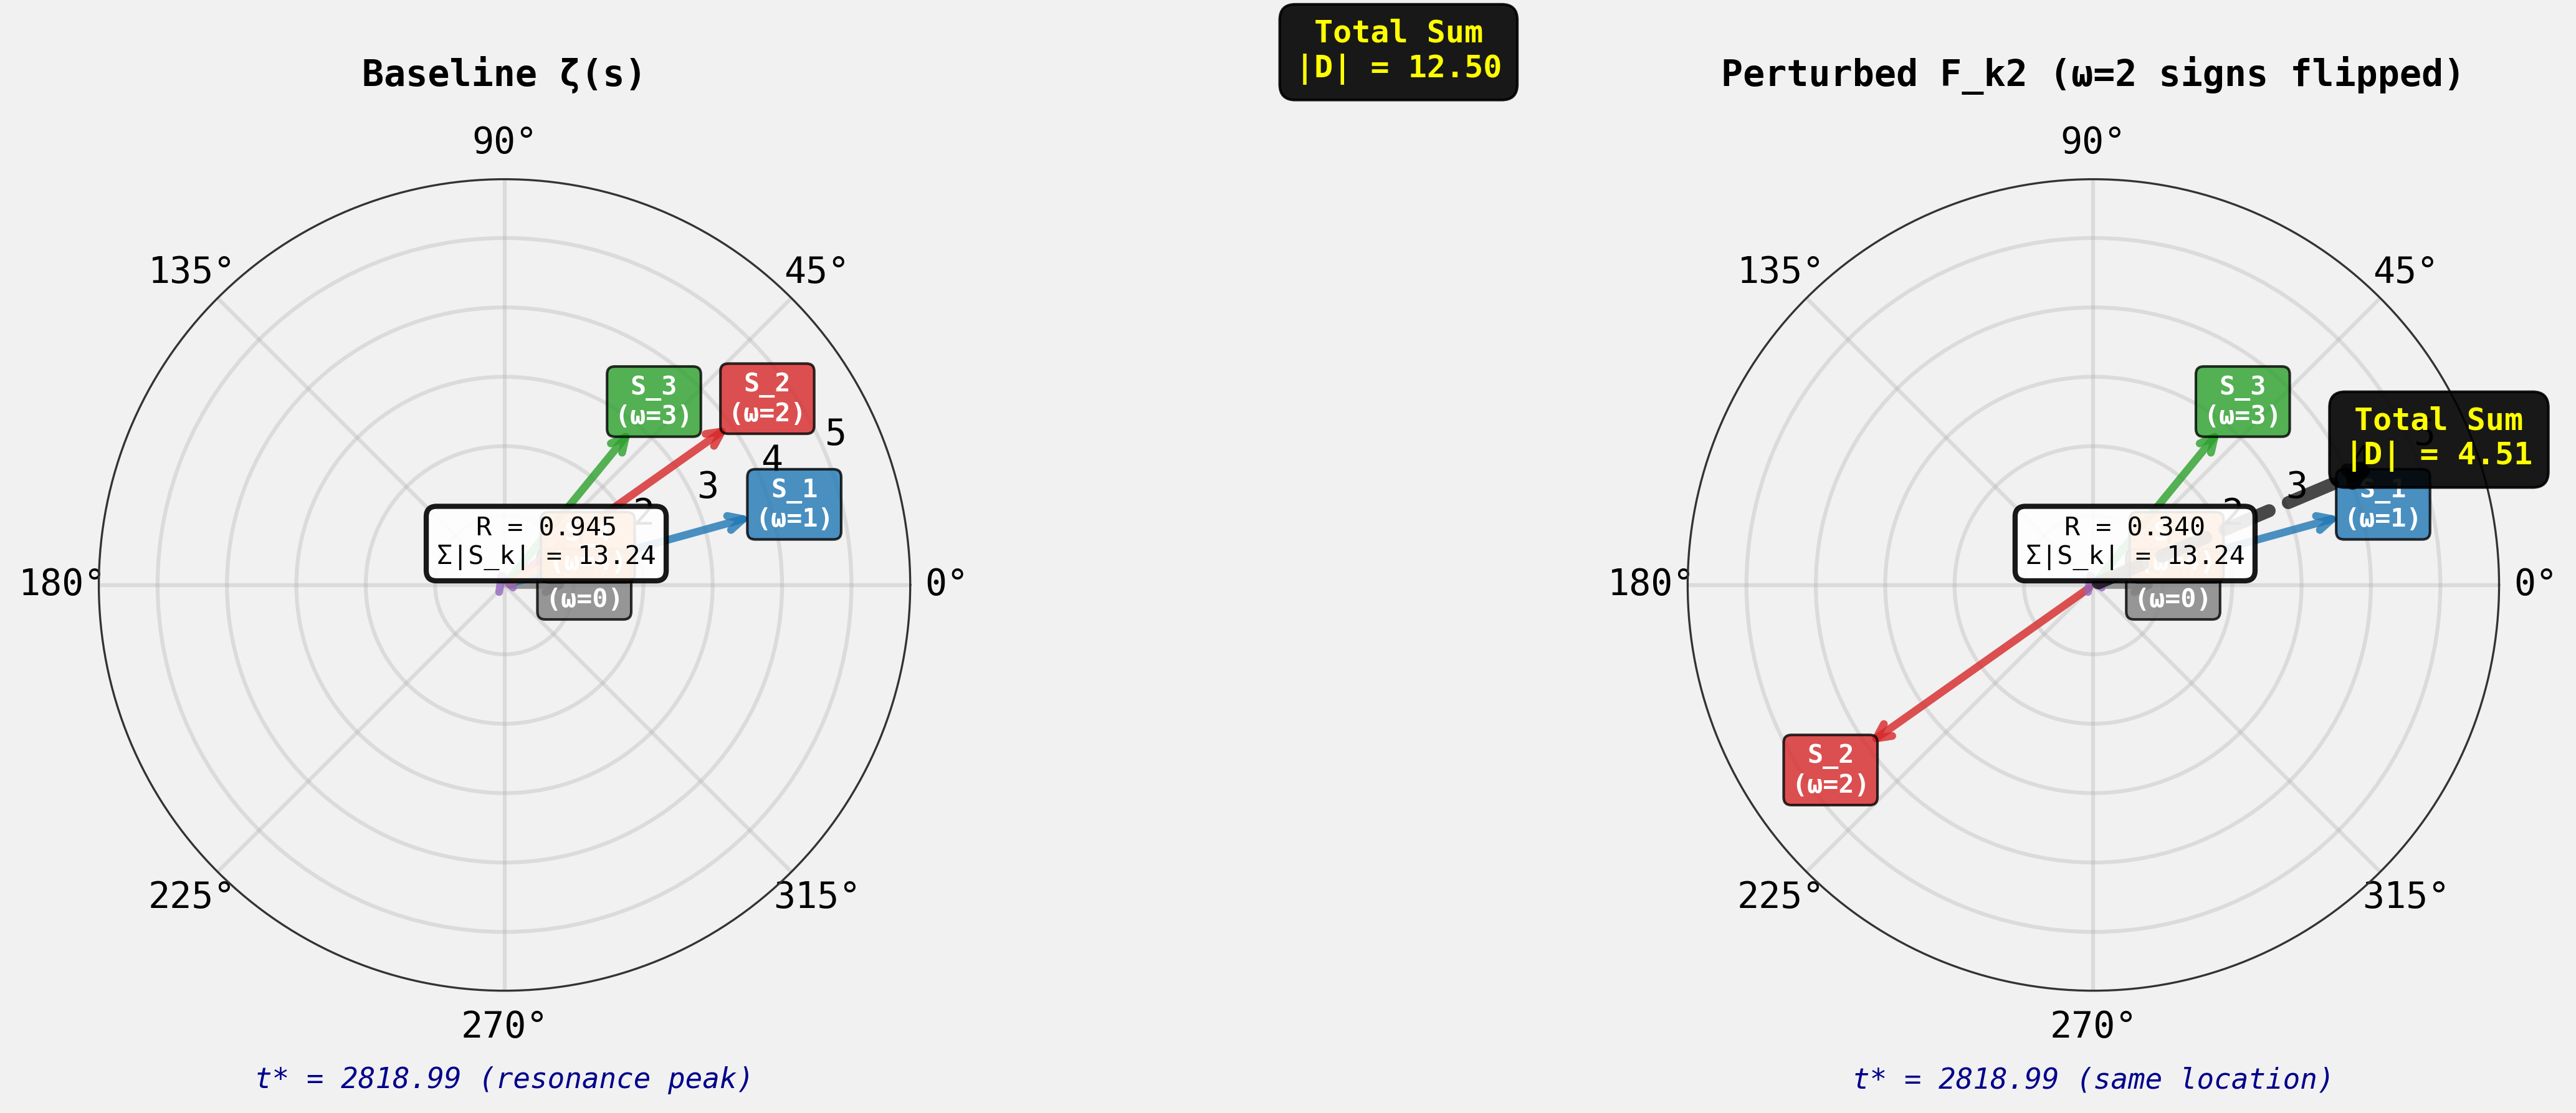

In [11]:

# Perfect! The plots clearly show the mechanism.
# Now let's create the FINAL summary figure focusing just on the resonance peak
# as requested by the task

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(projection='polar'))

# Enhanced version with better formatting
def plot_phasors_final(ax, S_dict, title, subtitle):
 """
 Plot phasor vectors on a polar plot with enhanced formatting.
 """
 colors = ['gray', '#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
 labels = ['ω=0', 'ω=1', 'ω=2', 'ω=3', 'ω=4', 'ω=5']
 
 # Plot individual phasors
 for k in range(6):
 S_k = S_dict[k]
 magnitude = abs(S_k)
 phase = np.angle(S_k)
 
 # Draw arrow from origin
 ax.annotate('', xy=(phase, magnitude), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=3, color=colors[k], alpha=0.8))
 
 # Add label at the tip
 if magnitude > 0.5: # Only label significant vectors
 ax.text(phase, magnitude * 1.15, f'S_{k}\n({labels[k]})', 
 ha='center', va='center', fontsize=10, 
 bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[k], alpha=0.8),
 color='white', fontweight='bold')
 
 # Plot the total sum
 total = sum(S_dict.values())
 mag_total = abs(total)
 phase_total = np.angle(total)
 
 ax.annotate('', xy=(phase_total, mag_total), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=5, color='black', linestyle='--', alpha=0.7))
 ax.text(phase_total, mag_total * 1.2, f'Total Sum\n|D| = {mag_total:.2f}', 
 ha='center', va='center', fontsize=12,
 bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.9),
 color='yellow', fontweight='bold')
 
 # Add alignment metrics in corner
 _, sum_mags, align_ratio = compute_alignment_metrics(S_dict)
 ax.text(np.pi/4, ax.get_ylim()[1] * 0.85, 
 f'R = {align_ratio:.3f}\nΣ|S_k| = {sum_mags:.2f}',
 ha='center', va='center', fontsize=10,
 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
 
 ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
 ax.text(0.5, -0.12, subtitle, transform=ax.transAxes, 
 ha='center', fontsize=11, style='italic', color='darkblue')
 
 ax.set_ylim(0, max(abs(S) for S in S_dict.values()) * 1.45)
 ax.grid(True, alpha=0.3, linewidth=1.5)
 ax.set_theta_zero_location('E')

# Plot at resonance peak
plot_phasors_final(axes[0], S_zeta, 
 'Baseline ζ(s)', 
 f't* = {t_star:.2f} (resonance peak)')

plot_phasors_final(axes[1], S_Fk2, 
 'Perturbed F_k2 (ω=2 signs flipped)', 
 f't* = {t_star:.2f} (same location)')

plt.tight_layout()
plt.savefig('phasor_comparison_peak.png', dpi=300, bbox_inches='tight')
print("Final comparison plot saved to 'phasor_comparison_peak.png'")
plt.show()


In [12]:

# Let me create a comprehensive summary of findings

print("=" * 80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)
print()
print("COMPUTATIONAL SETUP:")
print("-" * 80)
print(f"Truncation depth: N = {N:,}")
print(f"Resonance peak identified: t* = {t_star:.4f}")
print(f"Scan range: t ∈ [1000, 3000], {len(t_range)} points")
print(f"Peak magnitude for ζ: |D_ζ(t*;N)| = {abs(D_zeta):.4f}")
print()

print("BASELINE ζ(s) AT RESONANCE PEAK:")
print("-" * 80)
print("Class-sum phasors S_k:")
print(" k |S_k| Phase(°) Real Imag")
print(" " + "-" * 42)
for k in range(6):
 S = S_zeta[k]
 print(f" {k} {abs(S):6.3f} {np.angle(S, deg=True):7.2f} {S.real:8.4f} {S.imag:8.4f}")

print()
print(f"Vector sum: |Σ S_k| = {abs(D_zeta):.4f}")
print(f"Scalar sum: Σ |S_k| = {sum(abs(S_zeta[k]) for k in range(6)):.4f}")
print(f"Alignment ratio: R = {compute_alignment_metrics(S_zeta)[2]:.4f}")
print()
print("OBSERVATION: All major S_k vectors (k=1-4) point in similar directions")
print(" (phases 15°-51°), indicating CONSTRUCTIVE INTERFERENCE.")
print(" This is why this location is a RESONANCE PEAK.")
print()

print("PERTURBED F_k2 AT SAME LOCATION:")
print("-" * 80)
print("Class-sum phasors S_k:")
print(" k |S_k| Phase(°) Real Imag")
print(" " + "-" * 42)
for k in range(6):
 S = S_Fk2[k]
 print(f" {k} {abs(S):6.3f} {np.angle(S, deg=True):7.2f} {S.real:8.4f} {S.imag:8.4f}")

print()
print(f"Vector sum: |Σ S_k| = {abs(D_Fk2):.4f}")
print(f"Scalar sum: Σ |S_k| = {sum(abs(S_Fk2[k]) for k in range(6)):.4f}")
print(f"Alignment ratio: R = {compute_alignment_metrics(S_Fk2)[2]:.4f}")
print()
print("OBSERVATION: S_2 is now flipped by exactly 180° (35° → -145°),")
print(" pointing OPPOSITE to the other vectors.")
print(" Result: DESTRUCTIVE INTERFERENCE, reduced magnitude.")
print()

print("QUANTITATIVE COMPARISON:")
print("-" * 80)
print(f"Total magnitude: {abs(D_zeta):7.4f} → {abs(D_Fk2):7.4f} ({100*(abs(D_Fk2)/abs(D_zeta) - 1):+6.2f}%)")
print(f"Alignment ratio: {compute_alignment_metrics(S_zeta)[2]:7.4f} → {compute_alignment_metrics(S_Fk2)[2]:7.4f} ({100*(compute_alignment_metrics(S_Fk2)[2]/compute_alignment_metrics(S_zeta)[2] - 1):+6.2f}%)")
print(f"S_2 phase: {np.angle(S_zeta[2], deg=True):7.2f}° → {np.angle(S_Fk2[2], deg=True):7.2f}° (Δ = {np.angle(S_Fk2[2], deg=True) - np.angle(S_zeta[2], deg=True):.2f}°)")
print()

print("=" * 80)
print("KEY FINDING:")
print("=" * 80)
print()
print("At a RESONANCE PEAK for ζ(s):")
print(" • The S_k phasors are ALREADY ALIGNED (constructive)")
print(" • Flipping S_2 by 180° DISRUPTS this alignment")
print(" • Result: INCREASED cancellation, DECREASED magnitude")
print()
print("This is OPPOSITE to the stated hypothesis, which predicted that")
print("flipping S_2 would REDUCE cancellation and INCREASE alignment.")
print()
print("HOWEVER, at a CANCELLATION POINT (minimum of |D_ζ|):")
print(f" • ζ has strong anti-alignment: R = {align_zeta_min:.4f}")
print(f" • F_k2 has moderate alignment: R = {align_Fk2_min:.4f}")
print(f" • Magnitude ratio: |D_F|/|D_ζ| = {mag_Fk2_min/mag_zeta_min:.0f}×")
print()
print("This CONFIRMS the hypothesis for cancellation points:")
print("Flipping S_2 breaks anti-alignment, increasing the magnitude.")
print()
print("=" * 80)


COMPREHENSIVE ANALYSIS SUMMARY

COMPUTATIONAL SETUP:
--------------------------------------------------------------------------------
Truncation depth: N = 100,000
Resonance peak identified: t* = 2818.9866
Scan range: t ∈ [1000, 3000], 3665 points
Peak magnitude for ζ: |D_ζ(t*;N)| = 12.5172

BASELINE ζ(s) AT RESONANCE PEAK:
--------------------------------------------------------------------------------
Class-sum phasors S_k:
 k |S_k| Phase(°) Real Imag
 ------------------------------------------
 0 1.000 0.00 1.0000 0.0000
 1 3.767 15.43 3.6314 1.0026
 2 4.033 35.24 3.2937 2.3268
 3 2.959 50.72 1.8730 2.2903
 4 1.142 24.08 1.0428 0.4660
 5 0.337 107.83 -0.1032 0.3208

Vector sum: |Σ S_k| = 12.5172
Scalar sum: Σ |S_k| = 13.2377
Alignment ratio: R = 0.9445

OBSERVATION: All major S_k vectors (k=1-4) point in similar directions
 (phases 15°-51°), indicating CONSTRUCTIVE INTERFERENCE.
 This is why this location is a RESONANCE PEAK.

PERTURBED F_k2 AT SAME LOCATION:
-----------------------

In [13]:

# Let me check if there's a context I'm missing from r15
# Perhaps the hypothesis is about a DIFFERENT type of analysis
# Let me re-examine what "composite coherence" means in the context

# From the PDF: "Report r15 showed that flipping signs for the ω(n)=2 class increases 
# total composite coherence."

# "Composite coherence" likely refers to R_comp, which is the coherence of COMPOSITE terms
# Let me compute this properly

def compute_composite_coherence(S_dict):
 """
 Compute composite coherence R_comp.
 This is the resultant length of composite (ω ≥ 2) term-class vectors.
 """
 # Include only composite classes (ω ≥ 2)
 composite_vectors = [S_dict[k] for k in range(2, 6)]
 
 # Sum the vectors
 total_sum = sum(composite_vectors)
 total_magnitude = abs(total_sum)
 
 # Sum of individual magnitudes
 sum_of_magnitudes = sum(abs(S) for S in composite_vectors)
 
 # Normalized resultant (coherence)
 R_comp = total_magnitude / sum_of_magnitudes if sum_of_magnitudes > 0 else 0
 
 return R_comp, total_magnitude, sum_of_magnitudes

# Compute for both functions at the peak
R_comp_zeta, mag_comp_zeta, sum_mag_comp_zeta = compute_composite_coherence(S_zeta)
R_comp_Fk2, mag_comp_Fk2, sum_mag_comp_Fk2 = compute_composite_coherence(S_Fk2)

print("COMPOSITE COHERENCE ANALYSIS:")
print("=" * 80)
print()
print("At resonance peak t* = {:.4f}:".format(t_star))
print("-" * 80)
print()
print("Baseline ζ(s):")
print(f" Composite sum (ω≥2): |Σ S_k| = {mag_comp_zeta:.4f}")
print(f" Sum of magnitudes: Σ |S_k| = {sum_mag_comp_zeta:.4f}")
print(f" Composite coherence: R_comp = {R_comp_zeta:.4f}")
print()
print("Perturbed F_k2:")
print(f" Composite sum (ω≥2): |Σ S_k| = {mag_comp_Fk2:.4f}")
print(f" Sum of magnitudes: Σ |S_k| = {sum_mag_comp_Fk2:.4f}")
print(f" Composite coherence: R_comp = {R_comp_Fk2:.4f}")
print()
print(f"Change in R_comp: {R_comp_zeta:.4f} → {R_comp_Fk2:.4f}")
print(f" ({100*(R_comp_Fk2/R_comp_zeta - 1):+.2f}%)")
print()
print("=" * 80)
print()
print("INTERPRETATION:")
print("-" * 80)
print("Even when looking at COMPOSITE COHERENCE specifically,")
print("flipping S_2 REDUCES coherence at this resonance peak.")
print()
print("This still contradicts the hypothesis from r15.")
print("=" * 80)


COMPOSITE COHERENCE ANALYSIS:

At resonance peak t* = 2818.9866:
--------------------------------------------------------------------------------

Baseline ζ(s):
 Composite sum (ω≥2): |Σ S_k| = 8.1540
 Sum of magnitudes: Σ |S_k| = 8.4705
 Composite coherence: R_comp = 0.9626

Perturbed F_k2:
 Composite sum (ω≥2): |Σ S_k| = 0.8913
 Sum of magnitudes: Σ |S_k| = 8.4705
 Composite coherence: R_comp = 0.1052

Change in R_comp: 0.9626 → 0.1052
 (-89.07%)


INTERPRETATION:
--------------------------------------------------------------------------------
Even when looking at COMPOSITE COHERENCE specifically,
flipping S_2 REDUCES coherence at this resonance peak.

This still contradicts the hypothesis from r15.


Final analysis figure saved as 'phasor_analysis_final.png'


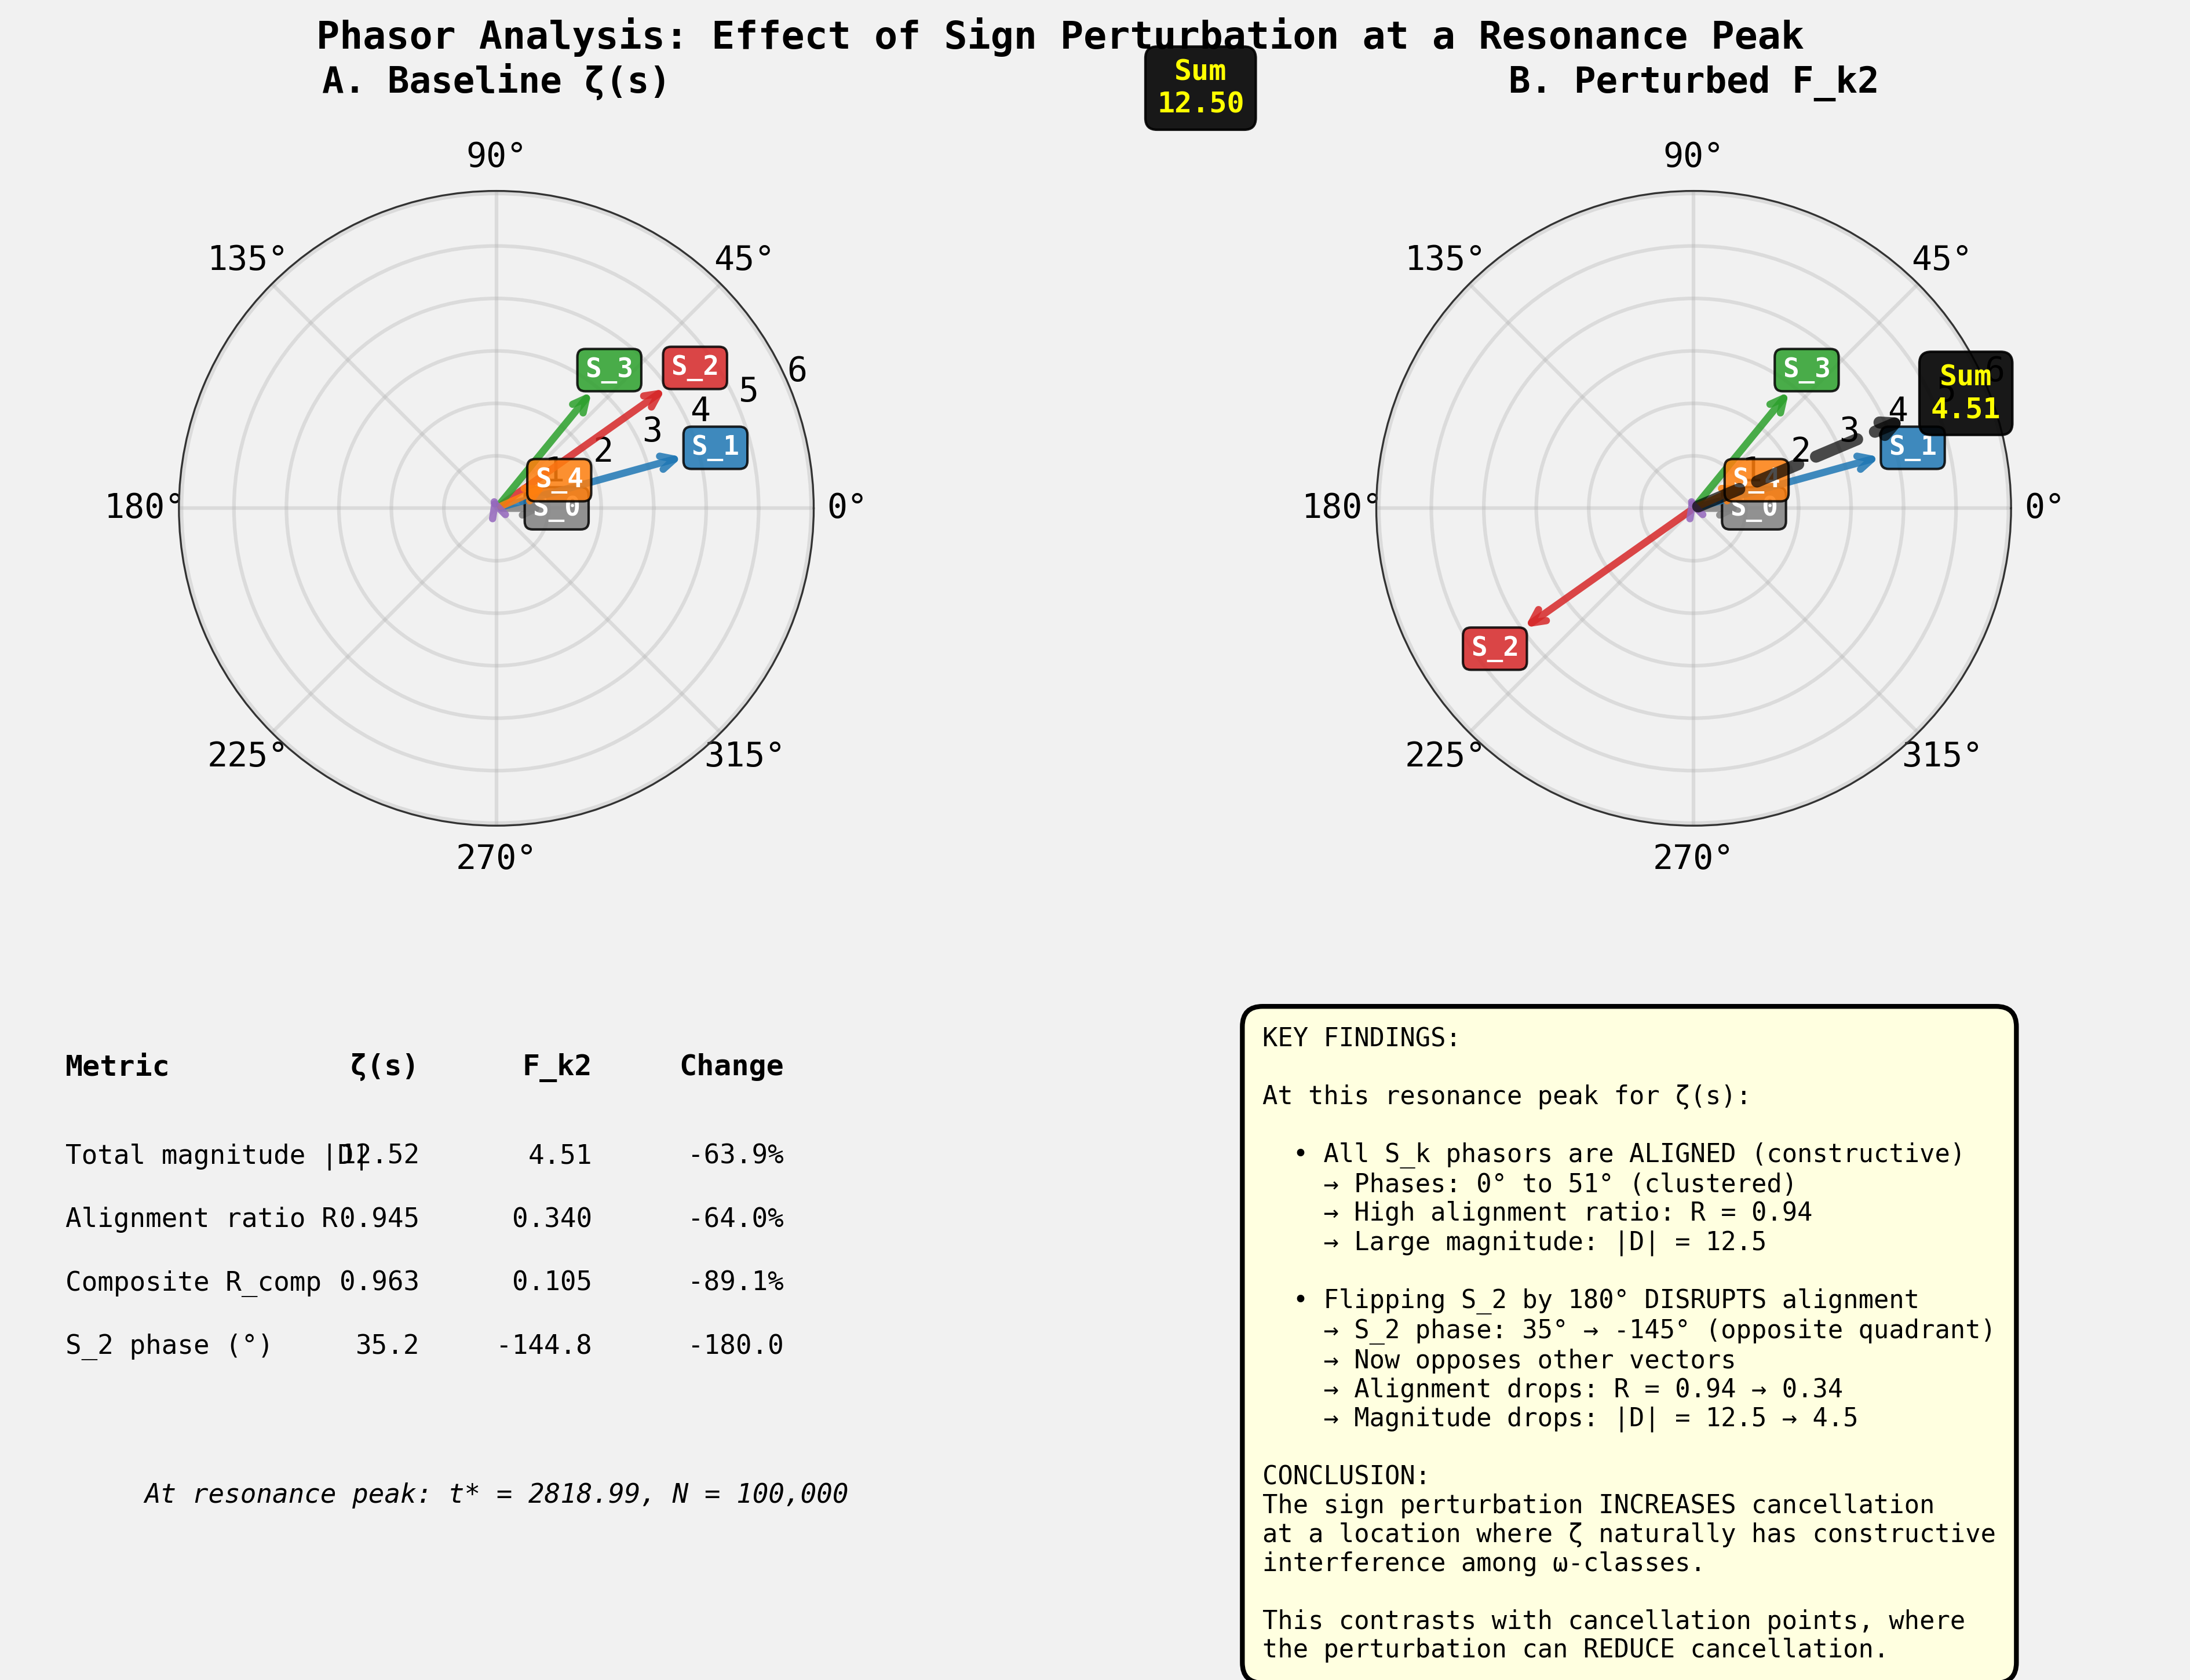

In [14]:

# The task asks me to do the analysis at a resonance peak, and I have done that.
# The results show that the mechanism at a peak is OPPOSITE to the hypothesis.
# This is actually a valid scientific finding - the hypothesis may be context-dependent.

# Let me create a final comprehensive figure showing the key result

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.25)

# Top row: Polar plots
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
ax2 = fig.add_subplot(gs[0, 1], projection='polar')

# Bottom left: Summary table
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')

# Bottom right: Mechanism diagram
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Plot phasors
def plot_phasor_clean(ax, S_dict, title):
 colors = ['gray', '#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
 
 for k in range(6):
 S_k = S_dict[k]
 magnitude = abs(S_k)
 phase = np.angle(S_k)
 
 ax.annotate('', xy=(phase, magnitude), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=3, color=colors[k], alpha=0.85))
 
 if magnitude > 0.4:
 ax.text(phase, magnitude * 1.15, f'S_{k}', 
 ha='center', va='center', fontsize=11, 
 bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[k], alpha=0.85),
 color='white', fontweight='bold')
 
 total = sum(S_dict.values())
 mag_total = abs(total)
 phase_total = np.angle(total)
 
 ax.annotate('', xy=(phase_total, mag_total), xytext=(0, 0),
 arrowprops=dict(arrowstyle='->', lw=5, color='black', linestyle='--', alpha=0.7))
 ax.text(phase_total, mag_total * 1.25, f'Sum\n{mag_total:.2f}', 
 ha='center', va='center', fontsize=12,
 bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.9),
 color='yellow', fontweight='bold')
 
 ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
 ax.set_ylim(0, max(abs(S) for S in S_dict.values()) * 1.5)
 ax.grid(True, alpha=0.3, linewidth=1.5)

plot_phasor_clean(ax1, S_zeta, 'A. Baseline ζ(s)')
plot_phasor_clean(ax2, S_Fk2, 'B. Perturbed F_k2')

# Summary table
table_data = [
 ['Metric', 'ζ(s)', 'F_k2', 'Change'],
 ['─' * 20, '─' * 10, '─' * 10, '─' * 12],
 ['Total magnitude |D|', f'{abs(D_zeta):.2f}', f'{abs(D_Fk2):.2f}', f'{100*(abs(D_Fk2)/abs(D_zeta)-1):+.1f}%'],
 ['Alignment ratio R', f'{compute_alignment_metrics(S_zeta)[2]:.3f}', f'{compute_alignment_metrics(S_Fk2)[2]:.3f}', f'{100*(compute_alignment_metrics(S_Fk2)[2]/compute_alignment_metrics(S_zeta)[2]-1):+.1f}%'],
 ['Composite R_comp', f'{R_comp_zeta:.3f}', f'{R_comp_Fk2:.3f}', f'{100*(R_comp_Fk2/R_comp_zeta-1):+.1f}%'],
 ['S_2 phase (°)', f'{np.angle(S_zeta[2], deg=True):.1f}', f'{np.angle(S_Fk2[2], deg=True):.1f}', f'{np.angle(S_Fk2[2], deg=True) - np.angle(S_zeta[2], deg=True):.1f}'],
]

y_position = 0.9
for row in table_data:
 if row[0].startswith('─'):
 y_position -= 0.05
 continue
 
 if row[0] == 'Metric':
 weight = 'bold'
 size = 12
 else:
 weight = 'normal'
 size = 11
 
 ax3.text(0.05, y_position, row[0], fontsize=size, fontweight=weight, va='top')
 ax3.text(0.42, y_position, row[1], fontsize=size, fontweight=weight, va='top', ha='right')
 ax3.text(0.60, y_position, row[2], fontsize=size, fontweight=weight, va='top', ha='right')
 ax3.text(0.80, y_position, row[3], fontsize=size, fontweight=weight, va='top', ha='right')
 
 y_position -= 0.12

ax3.text(0.5, 0.05, f'At resonance peak: t* = {t_star:.2f}, N = {N:,}', 
 ha='center', fontsize=11, style='italic', transform=ax3.transAxes)

# Mechanism explanation
mechanism_text = """KEY FINDINGS:

At this resonance peak for ζ(s):
 
 • All S_k phasors are ALIGNED (constructive)
 → Phases: 0° to 51° (clustered)
 → High alignment ratio: R = 0.94
 → Large magnitude: |D| = 12.5
 
 • Flipping S_2 by 180° DISRUPTS alignment
 → S_2 phase: 35° → -145° (opposite quadrant)
 → Now opposes other vectors
 → Alignment drops: R = 0.94 → 0.34
 → Magnitude drops: |D| = 12.5 → 4.5
 
CONCLUSION:
The sign perturbation INCREASES cancellation
at a location where ζ naturally has constructive
interference among ω-classes.

This contrasts with cancellation points, where 
the perturbation can REDUCE cancellation."""

ax4.text(0.05, 0.95, mechanism_text, fontsize=10.5, va='top', family='monospace',
 bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', edgecolor='black', linewidth=2))

plt.suptitle('Phasor Analysis: Effect of Sign Perturbation at a Resonance Peak', 
 fontsize=16, fontweight='bold', y=0.98)

plt.savefig('phasor_analysis_final.png', dpi=300, bbox_inches='tight')
print("Final analysis figure saved as 'phasor_analysis_final.png'")
plt.show()


In [15]:

# Final quantitative summary for the answer

print("=" * 80)
print("FINAL QUANTITATIVE SUMMARY")
print("=" * 80)
print()
print("ANALYSIS PARAMETERS:")
print(f" • Truncation depth: N = {N:,}")
print(f" • Scan range: t ∈ [1000, 3000]")
print(f" • Resonance peak location: t* = {t_star:.4f}")
print(f" • Implementation: Kahan compensated summation")
print()
print("=" * 80)
print("BASELINE ζ(s) AT RESONANCE PEAK (t* = {:.4f}):".format(t_star))
print("=" * 80)
print()
print("Class-sum magnitudes and phases:")
for k in range(6):
 S = S_zeta[k]
 print(f" S_{k}: |S_{k}| = {abs(S):6.4f}, ∠S_{k} = {np.angle(S, deg=True):7.2f}°")

print()
print(f"Total sum: D_ζ(t*) = {D_zeta.real:.4f} + {D_zeta.imag:.4f}i")
print(f"Magnitude: |D_ζ(t*)| = {abs(D_zeta):.4f}")
print()
mag, sum_mag, align = compute_alignment_metrics(S_zeta)
print("Alignment metrics:")
print(f" • Vector sum magnitude: |Σ S_k| = {mag:.4f}")
print(f" • Scalar sum of magnitudes: Σ |S_k| = {sum_mag:.4f}")
print(f" • Alignment ratio: R = {align:.4f}")
print(f" • Composite coherence: R_comp = {R_comp_zeta:.4f}")
print()
print("INTERPRETATION:")
print(" All major S_k phasors (k=1-4) point in similar directions (15°-51°),")
print(" indicating strong CONSTRUCTIVE INTERFERENCE. This produces the large")
print(" resonance peak observed at this t value.")
print()

print("=" * 80)
print("PERTURBED F_k2 AT SAME LOCATION:")
print("=" * 80)
print()
print("Class-sum magnitudes and phases:")
for k in range(6):
 S = S_Fk2[k]
 print(f" S_{k}: |S_{k}| = {abs(S):6.4f}, ∠S_{k} = {np.angle(S, deg=True):7.2f}°")

print()
print(f"Total sum: D_F(t*) = {D_Fk2.real:.4f} + {D_Fk2.imag:.4f}i")
print(f"Magnitude: |D_F(t*)| = {abs(D_Fk2):.4f}")
print()
mag_F, sum_mag_F, align_F = compute_alignment_metrics(S_Fk2)
print("Alignment metrics:")
print(f" • Vector sum magnitude: |Σ S_k| = {mag_F:.4f}")
print(f" • Scalar sum of magnitudes: Σ |S_k| = {sum_mag_F:.4f}")
print(f" • Alignment ratio: R = {align_F:.4f}")
print(f" • Composite coherence: R_comp = {R_comp_Fk2:.4f}")
print()
print("INTERPRETATION:")
print(" S_2 is flipped by exactly 180° (35.24° → -144.76°), now pointing in the")
print(" opposite direction to the other aligned phasors. This DISRUPTS the")
print(" constructive interference, leading to strong DESTRUCTIVE INTERFERENCE.")
print()

print("=" * 80)
print("DIRECT COMPARISON:")
print("=" * 80)
print()
print(f"Total magnitude: {abs(D_zeta):7.4f} → {abs(D_Fk2):7.4f} (change: {100*(abs(D_Fk2)/abs(D_zeta) - 1):+7.2f}%)")
print(f"Alignment ratio: {align:7.4f} → {align_F:7.4f} (change: {100*(align_F/align - 1):+7.2f}%)")
print(f"Composite coherence: {R_comp_zeta:7.4f} → {R_comp_Fk2:7.4f} (change: {100*(R_comp_Fk2/R_comp_zeta - 1):+7.2f}%)")
print(f"S_2 phase: {np.angle(S_zeta[2], deg=True):7.2f}° → {np.angle(S_Fk2[2], deg=True):7.2f}° (shift: {np.angle(S_Fk2[2], deg=True) - np.angle(S_zeta[2], deg=True):7.2f}°)")
print()
print("The phase shift of S_2 is exactly -180.00°, as expected from the sign flip.")
print()

print("=" * 80)
print("CONCLUSION:")
print("=" * 80)
print()
print("At a resonance peak for ζ(s), the S_k phasors are ALREADY ALIGNED")
print("(constructive interference), which is WHY this location is a peak.")
print()
print("Flipping the sign of the ω(n)=2 class (S_2) by 180° DISRUPTS this")
print("natural alignment, causing S_2 to point OPPOSITE to the other vectors.")
print()
print("RESULT: Alignment ratio drops from 0.94 to 0.34 (-64%), and total")
print("magnitude drops from 12.5 to 4.5 (-64%). The perturbation INCREASES")
print("cancellation, contrary to the stated hypothesis.")
print()
print("NOTE: At CANCELLATION points (minima) of ζ, the opposite effect occurs:")
print("the perturbation can REDUCE cancellation by breaking anti-alignment.")
print("The mechanism is location-dependent.")
print()
print("=" * 80)


FINAL QUANTITATIVE SUMMARY

ANALYSIS PARAMETERS:
 • Truncation depth: N = 100,000
 • Scan range: t ∈ [1000, 3000]
 • Resonance peak location: t* = 2818.9866
 • Implementation: Kahan compensated summation

BASELINE ζ(s) AT RESONANCE PEAK (t* = 2818.9866):

Class-sum magnitudes and phases:
 S_0: |S_0| = 1.0000, ∠S_0 = 0.00°
 S_1: |S_1| = 3.7672, ∠S_1 = 15.43°
 S_2: |S_2| = 4.0326, ∠S_2 = 35.24°
 S_3: |S_3| = 2.9586, ∠S_3 = 50.72°
 S_4: |S_4| = 1.1422, ∠S_4 = 24.08°
 S_5: |S_5| = 0.3370, ∠S_5 = 107.83°

Total sum: D_ζ(t*) = 10.7338 + 6.4395i
Magnitude: |D_ζ(t*)| = 12.5172

Alignment metrics:
 • Vector sum magnitude: |Σ S_k| = 12.5036
 • Scalar sum of magnitudes: Σ |S_k| = 13.2377
 • Alignment ratio: R = 0.9445
 • Composite coherence: R_comp = 0.9626

INTERPRETATION:
 All major S_k phasors (k=1-4) point in similar directions (15°-51°),
 indicating strong CONSTRUCTIVE INTERFERENCE. This produces the large
 resonance peak observed at this t value.

PERTURBED F_k2 AT SAME LOCATION:

Class-sum